In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

In [31]:
x = np.load("/content/drive/MyDrive/dataset/csv-3s/X_windows_3s_full_ds.npy")
y_disease = np.load("/content/drive/MyDrive/dataset/csv-3s/Y_disease_3s_labels.npy")
y_activity = np.load("/content/drive/MyDrive/dataset/csv-3s/Y_activity_3s_labels.npy")


In [32]:
print("X shape:", x.shape)
print("Disease labels shape:", y_disease.shape)
print("Activity labels shape:", y_activity.shape)

X shape: (48776, 300, 12)
Disease labels shape: (48776,)
Activity labels shape: (48776,)


In [33]:
X_train, X_temp, y_disease_train, y_disease_temp, y_activity_train, y_activity_temp = train_test_split(x, y_disease, y_activity, test_size=0.3, random_state=42, stratify = y_disease)
print("X_train shape:", X_train.shape)
print("y_disease_train shape:", y_disease_train.shape)
print("y_activity_train shape:", y_activity_train.shape)

X_train shape: (34143, 300, 12)
y_disease_train shape: (34143,)
y_activity_train shape: (34143,)


In [34]:
X_val, X_test, y_disease_val, y_disease_test, y_activity_val, y_activity_test = train_test_split(
    X_temp, y_disease_temp, y_activity_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_disease_temp
)

print("Train shapes:", X_train.shape, y_disease_train.shape, y_activity_train.shape)
print("Val shapes:", X_val.shape, y_disease_val.shape, y_activity_val.shape)
print("Test shapes:", X_test.shape, y_disease_test.shape, y_activity_test.shape)

Train shapes: (34143, 300, 12) (34143,) (34143,)
Val shapes: (7316, 300, 12) (7316,) (7316,)
Test shapes: (7317, 300, 12) (7317,) (7317,)


In [35]:
import numpy as np
from collections import Counter

print("Train disease distribution:", Counter(y_disease_train))
print("Val disease distribution:", Counter(y_disease_val))
print("Test disease distribution:", Counter(y_disease_test))

Train disease distribution: Counter({np.int16(1): 20093, np.int16(2): 8299, np.int16(0): 5751})
Val disease distribution: Counter({np.int16(1): 4305, np.int16(2): 1778, np.int16(0): 1233})
Test disease distribution: Counter({np.int16(1): 4306, np.int16(2): 1779, np.int16(0): 1232})


In [36]:
import pandas as pd
(unique, counts) = np.unique(y_disease_train, return_counts=True)
print(pd.DataFrame({'class': unique, 'count': counts}))

   class  count
0      0   5751
1      1  20093
2      2   8299


In [37]:
from sklearn.preprocessing import StandardScaler
N, T, F = X_train.shape
scaler = StandardScaler()
X_train_2d = X_train.reshape(-1, F)
X_val_2d   = X_val.reshape(-1, F)
X_test_2d  = X_test.reshape(-1, F)
scaler.fit(X_train_2d)
X_train_scaled = scaler.transform(X_train_2d).reshape(N, T, F)
X_val_scaled   = scaler.transform(X_val_2d).reshape(X_val.shape[0], T, F)
X_test_scaled  = scaler.transform(X_test_2d).reshape(X_test.shape[0], T, F)


In [38]:
from sklearn.utils.class_weight import compute_class_weight
disease_classes = np.unique(y_disease_train)
disease_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=disease_classes,
    y=y_disease_train
)

# Convert to dictionary: {class_index: weight}
disease_class_weights = {i: w for i, w in zip(disease_classes, disease_weights_array)}
print("Disease class weights:", disease_class_weights)


Disease class weights: {np.int16(0): np.float64(1.9789601808381152), np.int16(1): np.float64(0.5664161648335241), np.int16(2): np.float64(1.3713700445836847)}


In [39]:
print("y_disease_train shape:", y_disease_train.shape)
print("sample_weights[0] shape:", np.array([disease_class_weights[c] for c in y_disease_train]).shape)

print("y_activity_train shape:", y_activity_train.shape)
print("sample_weights[1] shape:", np.ones(len(y_activity_train)).shape)


y_disease_train shape: (34143,)
sample_weights[0] shape: (34143,)
y_activity_train shape: (34143,)
sample_weights[1] shape: (34143,)


In [40]:
import tensorflow as tf
class attention_layer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
    def build(self, input_shape):
        self.W=self.add_weight(name="att_weight", shape=(input_shape[-1],input_shape[-1]), initializer="glorot_uniform", trainable=True)
        self.b=self.add_weight(name="att_bias", shape=(input_shape[-1],), initializer="zeros", trainable=True)
        self.v=self.add_weight(name="att_v", shape=(input_shape[-1],1), initializer="glorot_uniform", trainable=True)
        super().build(input_shape)
    def call(self, inputs, mask=None):
        u = tf.tanh(tf.matmul(inputs,self.W)+self.b)
        scores = tf.matmul(u,self.v)
        alpha = tf.nn.softmax(scores, axis=1)
        context_vector = tf.reduce_sum(inputs*alpha, axis=1)
        return context_vector


In [41]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K
from tensorflow.keras.regularizers import l2
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import Input, Dense, Conv1D, MaxPooling1D, LSTM, Dropout, Attention, Permute, Multiply, Lambda, Concatenate, GlobalAveragePooling1D, BatchNormalization

In [42]:
from sklearn.metrics import f1_score
from tensorflow.keras.callbacks import Callback

# Custom callback to compute F1 after each epoch
class F1ScoreCallback(Callback):
    def __init__(self, val_data, batch_size=32):
        super().__init__()
        self.validation_data = val_data
        self.batch_size = batch_size
        self.val_f1s = []

    def on_epoch_end(self, epoch, logs=None):
        X_val, y_val_dict = self.validation_data
        y_true = y_val_dict["disease_output"]

        # Get predictions
        y_pred = self.model.predict(X_val, batch_size=self.batch_size, verbose=0)
        y_pred_classes = np.argmax(y_pred[0], axis=1)  # [0] -> disease_output

        # Compute macro F1
        f1 = f1_score(y_true, y_pred_classes, average="macro")
        self.val_f1s.append(f1)

        print(f"\nEpoch {epoch+1}: val_macro_f1 = {f1:.4f}")
        logs["val_macro_f1"] = f1


In [43]:
f1_callback = F1ScoreCallback(
    val_data=(X_val_scaled, {"disease_output": y_disease_val, "activity_output": y_activity_val}),
    batch_size=64)

In [44]:

def build_multi_task_model(timesteps=100, features=12, num_disease=3, num_activities=10, conv_filter=64, lstm_units=64, dropout_rate=0.3):
    input_layer = tf.keras.layers.Input(shape=(timesteps, features), name="inputs")

    #CNN
    x=layers.Conv1D(conv_filter, kernel_size=7, activation='relu',kernel_regularizer=l2(0.001), padding="same")(input_layer)
    x=layers.BatchNormalization()(x)
    x=layers.Dropout(dropout_rate)(x)
    x=layers.Conv1D(conv_filter, kernel_size=5, activation='relu',kernel_regularizer=l2(0.001), padding="same")(x)
    x=layers.BatchNormalization()(x)
    x=layers.MaxPooling1D(pool_size=2)(x)
    x=layers.Dropout(dropout_rate)(x)

    #BiLSTM
    x=layers.LSTM(lstm_units,kernel_regularizer=l2(0.001), return_sequences=True)(x)
    x=Dropout(0.3)(x)

    #Attention
    atten_out=attention_layer()(x)
    x=Dense(64, activation='relu', kernel_regularizer=l2(0.001))(atten_out)
    x=Dropout(0.3)(x)

    #Disease output
    disease_output = Dense(num_disease, activation='softmax', name='disease_output')(x)

    #Activity output
    activity_output = Dense(num_activities, activation='softmax', name='activity_output')(x)

    model=Model(inputs=input_layer, outputs=[disease_output, activity_output])
    return model

In [45]:
import tensorflow as tf
from tensorflow.keras import backend as K

class MacroF1(tf.keras.metrics.Metric):
    def __init__(self, name="macro_f1", **kwargs):
        super(MacroF1, self).__init__(name=name, **kwargs)
        self.f1 = self.add_weight(name="f1", initializer="zeros")
        self.count = self.add_weight(name="count", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(y_true, tf.int32)
        y_pred = tf.argmax(y_pred, axis=1)

        # Compute F1 using py_function
        f1 = tf.py_function(self._compute_f1, (y_true, y_pred), tf.float32)
        f1.set_shape([])  # <-- FIX: tell TF this is a scalar

        self.f1.assign_add(f1)
        self.count.assign_add(1.0)

    def result(self):
        return self.f1 / self.count

    def reset_states(self):
        self.f1.assign(0.0)
        self.count.assign(0.0)

    def _compute_f1(self, y_true, y_pred):
        from sklearn.metrics import f1_score
        f1 = f1_score(y_true.numpy(), y_pred.numpy(), average="macro")
        return tf.constant(f1, dtype=tf.float32)  # <-- FIX

In [46]:
input_shape = (X_train.shape[1], X_train.shape[2])
num_disease = len(np.unique(y_disease_train))
num_activities = len(np.unique(y_activity_train))

model = build_multi_task_model(timesteps=input_shape[0], features=input_shape[1], num_disease=num_disease, num_activities=num_activities)
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss={
        'disease_output': 'sparse_categorical_crossentropy',
        'activity_output': 'sparse_categorical_crossentropy'
    },
    metrics={
        "disease_output": ["accuracy", MacroF1(name="macro_f1")],
        'activity_output': 'accuracy'
    }
)

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint_path = "/content/checkpoints/epoch_{epoch:02d}_val_loss_{val_loss:.4f}.h5"

checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=False,   # save full model (set True if only weights needed)
    save_freq="epoch",         # save at every epoch
    monitor="val_loss",        # metric to monitor
    save_best_only=False,      # False → save all epochs
    verbose=1
)

In [47]:
history = model.fit(
    X_train_scaled,
    [y_disease_train, y_activity_train],   # <-- list, not dict
    validation_data = (
        X_val_scaled,
        [y_disease_val, y_activity_val]    # <-- also list
    ),
    epochs=100,
    batch_size=128,
    sample_weight=[
        np.array([disease_class_weights[c] for c in y_disease_train]),  # weights for disease_output
        np.ones(len(y_activity_train))                                  # weights for activity_output
    ],
    callbacks=[checkpoint_callback, f1_callback]
)

Epoch 1/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - activity_output_accuracy: 0.6004 - activity_output_loss: 1.3406 - disease_output_accuracy: 0.3618 - disease_output_loss: 1.1236 - disease_output_macro_f1: 0.3164 - loss: 2.6933
Epoch 1: saving model to /content/checkpoints/epoch_01_val_loss_3.2542.h5



Epoch 1: val_macro_f1 = 0.3688
267/267 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - activity_output_accuracy: 0.6008 - activity_output_loss: 1.3393 - disease_output_accuracy: 0.3618 - disease_output_loss: 1.1235 - disease_output_macro_f1: 0.3165 - loss: 2.6919 - val_activity_output_accuracy: 0.5163 - val_activity_output_loss: 2.0135 - val_disease_output_accuracy: 0.4388 - val_disease_output_loss: 1.0552 - val_disease_output_macro_f1: 0.3666 - val_loss: 3.2542 - val_macro_f1: 0.3688
Epoch 2/100
266/267 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - activity_output_accuracy: 0.7828 - activity_output_loss: 0.6681 - disease_output_accuracy: 0.3687 - disease_output_loss: 1.0774 - disease_output_macro_f1: 0.3502 - loss: 1.9266
Epoch 2: saving model to /content/checkpoints/epoch_02_val_loss_1.9789.h5



Epoch 2: val_macro_f1 = 0.3266
267/267 ━━━━━━━━━━━━━━━━━━━━ 20s 41ms/step - activity_output_accuracy: 0.7828 - activity_output_loss: 0.6678 - disease_output_accuracy: 0.3686 - disease_output_loss: 1.0774 - disease_output_macro_f1: 0.3502 - loss: 1.9263 - val_activity_output_accuracy: 0.7038 - val_activity_output_loss: 0.7773 - val_disease_output_accuracy: 0.3320 - val_disease_output_loss: 1.0405 - val_disease_output_macro_f1: 0.3256 - val_loss: 1.9789 - val_macro_f1: 0.3266
Epoch 3/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - activity_output_accuracy: 0.8138 - activity_output_loss: 0.5555 - disease_output_accuracy: 0.3614 - disease_output_loss: 1.0393 - disease_output_macro_f1: 0.3518 - loss: 1.7522
Epoch 3: saving model to /content/checkpoints/epoch_03_val_loss_1.6745.h5



Epoch 3: val_macro_f1 = 0.3514
267/267 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - activity_output_accuracy: 0.8138 - activity_output_loss: 0.5554 - disease_output_accuracy: 0.3614 - disease_output_loss: 1.0393 - disease_output_macro_f1: 0.3518 - loss: 1.7521 - val_activity_output_accuracy: 0.8181 - val_activity_output_loss: 0.5069 - val_disease_output_accuracy: 0.3770 - val_disease_output_loss: 1.0213 - val_disease_output_macro_f1: 0.3488 - val_loss: 1.6745 - val_macro_f1: 0.3514
Epoch 4/100
265/267 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - activity_output_accuracy: 0.8417 - activity_output_loss: 0.4935 - disease_output_accuracy: 0.3712 - disease_output_loss: 1.0239 - disease_output_macro_f1: 0.3668 - loss: 1.6617
Epoch 4: saving model to /content/checkpoints/epoch_04_val_loss_1.6729.h5



Epoch 4: val_macro_f1 = 0.3665
267/267 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - activity_output_accuracy: 0.8417 - activity_output_loss: 0.4935 - disease_output_accuracy: 0.3711 - disease_output_loss: 1.0238 - disease_output_macro_f1: 0.3668 - loss: 1.6616 - val_activity_output_accuracy: 0.8215 - val_activity_output_loss: 0.5049 - val_disease_output_accuracy: 0.3701 - val_disease_output_loss: 1.0302 - val_disease_output_macro_f1: 0.3671 - val_loss: 1.6729 - val_macro_f1: 0.3665
Epoch 5/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - activity_output_accuracy: 0.8613 - activity_output_loss: 0.4493 - disease_output_accuracy: 0.3757 - disease_output_loss: 1.0084 - disease_output_macro_f1: 0.3724 - loss: 1.5943
Epoch 5: saving model to /content/checkpoints/epoch_05_val_loss_1.4953.h5


...


Epoch 96: val_macro_f1 = 0.6401
267/267 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - activity_output_accuracy: 0.9539 - activity_output_loss: 0.1426 - disease_output_accuracy: 0.6689 - disease_output_loss: 0.5862 - disease_output_macro_f1: 0.6538 - loss: 0.8920 - val_activity_output_accuracy: 0.9460 - val_activity_output_loss: 0.1799 - val_disease_output_accuracy: 0.6547 - val_disease_output_loss: 0.6930 - val_disease_output_macro_f1: 0.6369 - val_loss: 1.0344 - val_macro_f1: 0.6401
Epoch 97/100
266/267 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - activity_output_accuracy: 0.9513 - activity_output_loss: 0.1491 - disease_output_accuracy: 0.6726 - disease_output_loss: 0.5957 - disease_output_macro_f1: 0.6567 - loss: 0.9083
Epoch 97: saving model to /content/checkpoints/epoch_97_val_loss_0.9683.h5



Epoch 97: val_macro_f1 = 0.6470
267/267 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - activity_output_accuracy: 0.9513 - activity_output_loss: 0.1490 - disease_output_accuracy: 0.6726 - disease_output_loss: 0.5958 - disease_output_macro_f1: 0.6567 - loss: 0.9083 - val_activity_output_accuracy: 0.9549 - val_activity_output_loss: 0.1384 - val_disease_output_accuracy: 0.6627 - val_disease_output_loss: 0.6680 - val_disease_output_macro_f1: 0.6427 - val_loss: 0.9683 - val_macro_f1: 0.6470
Epoch 98/100
266/267 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - activity_output_accuracy: 0.9533 - activity_output_loss: 0.1447 - disease_output_accuracy: 0.6814 - disease_output_loss: 0.5892 - disease_output_macro_f1: 0.6646 - loss: 0.8971
Epoch 98: saving model to /content/checkpoints/epoch_98_val_loss_0.9825.h5



Epoch 98: val_macro_f1 = 0.6528
267/267 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - activity_output_accuracy: 0.9533 - activity_output_loss: 0.1446 - disease_output_accuracy: 0.6813 - disease_output_loss: 0.5892 - disease_output_macro_f1: 0.6645 - loss: 0.8972 - val_activity_output_accuracy: 0.9531 - val_activity_output_loss: 0.1551 - val_disease_output_accuracy: 0.6677 - val_disease_output_loss: 0.6637 - val_disease_output_macro_f1: 0.6496 - val_loss: 0.9825 - val_macro_f1: 0.6528
Epoch 99/100
265/267 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - activity_output_accuracy: 0.9548 - activity_output_loss: 0.1413 - disease_output_accuracy: 0.6783 - disease_output_loss: 0.5865 - disease_output_macro_f1: 0.6640 - loss: 0.8919
Epoch 99: saving model to /content/checkpoints/epoch_99_val_loss_0.9699.h5



Epoch 99: val_macro_f1 = 0.6466
267/267 ━━━━━━━━━━━━━━━━━━━━ 19s 35ms/step - activity_output_accuracy: 0.9547 - activity_output_loss: 0.1414 - disease_output_accuracy: 0.6782 - disease_output_loss: 0.5866 - disease_output_macro_f1: 0.6639 - loss: 0.8921 - val_activity_output_accuracy: 0.9531 - val_activity_output_loss: 0.1521 - val_disease_output_accuracy: 0.6580 - val_disease_output_loss: 0.6567 - val_disease_output_macro_f1: 0.6432 - val_loss: 0.9699 - val_macro_f1: 0.6466
Epoch 100/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - activity_output_accuracy: 0.9550 - activity_output_loss: 0.1356 - disease_output_accuracy: 0.6733 - disease_output_loss: 0.5876 - disease_output_macro_f1: 0.6599 - loss: 0.8877
Epoch 100: saving model to /content/checkpoints/epoch_100_val_loss_1.0046.h5



Epoch 100: val_macro_f1 = 0.6348
267/267 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - activity_output_accuracy: 0.9549 - activity_output_loss: 0.1356 - disease_output_accuracy: 0.6733 - disease_output_loss: 0.5876 - disease_output_macro_f1: 0.6599 - loss: 0.8877 - val_activity_output_accuracy: 0.9516 - val_activity_output_loss: 0.1680 - val_disease_output_accuracy: 0.6460 - val_disease_output_loss: 0.6791 - val_disease_output_macro_f1: 0.6309 - val_loss: 1.0046 - val_macro_f1: 0.6348


In [52]:
import os
save_dir = "/content/drive/MyDrive/dataset/csv-3s/"   # e.g. in Colab
os.makedirs(save_dir, exist_ok=True)
model_path = os.path.join(save_dir, "1cnn_lstm_1dense_3s_10%_100epoch_64.keras")
model.save(model_path)
print(f"Model saved at: {model_path}")


Model saved at: /content/drive/MyDrive/dataset/csv-3s/1cnn_lstm_1dense_3s_10%_100epoch_64.keras


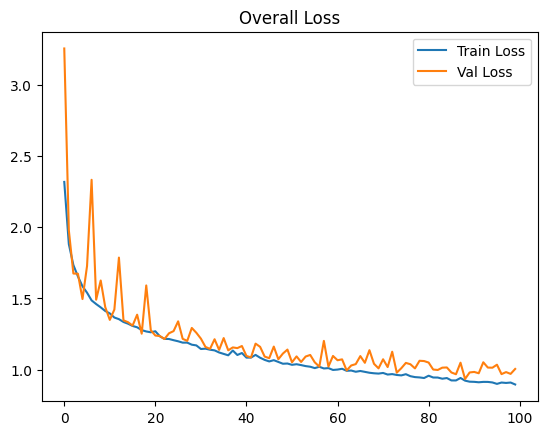

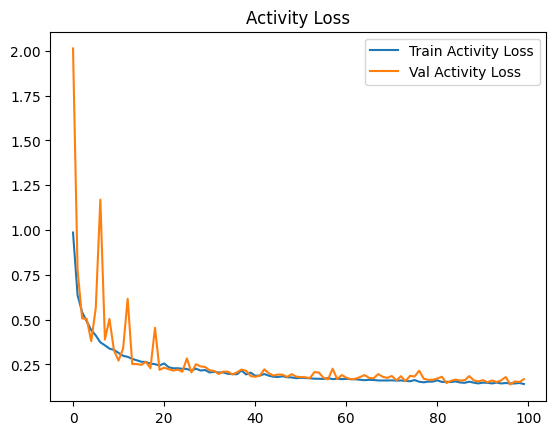

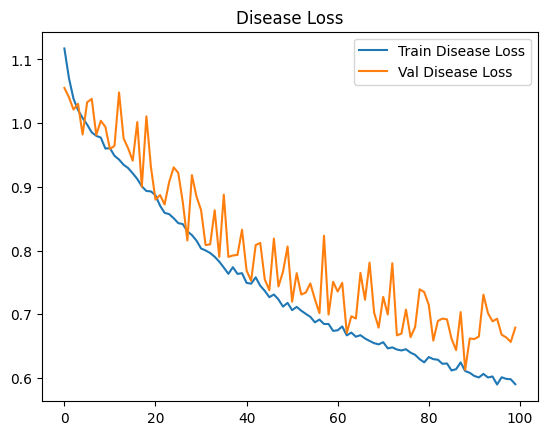

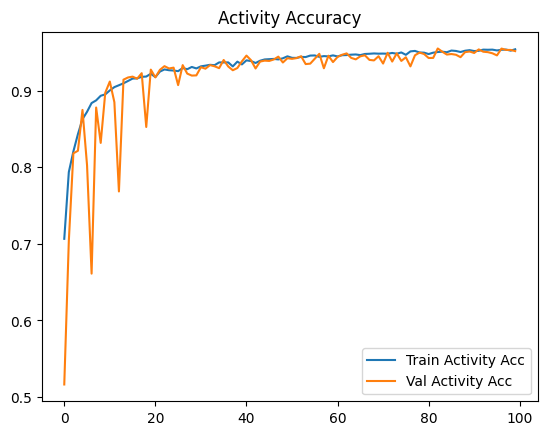

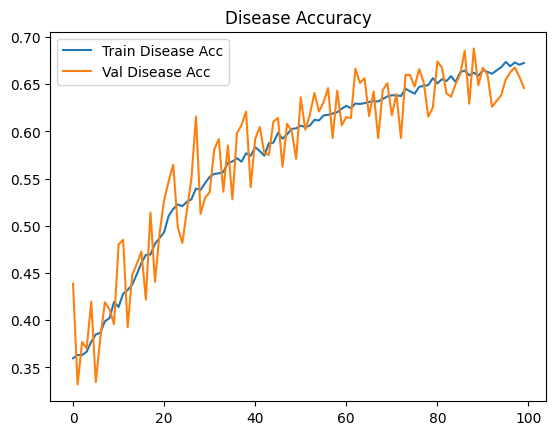

In [53]:
import matplotlib.pyplot as plt

# ---- Plot overall loss ----
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Overall Loss")
plt.show()

# ---- Plot activity loss ----
plt.plot(history.history["activity_output_loss"], label="Train Activity Loss")
plt.plot(history.history["val_activity_output_loss"], label="Val Activity Loss")
plt.legend()
plt.title("Activity Loss")
plt.show()

# ---- Plot disease loss ----
plt.plot(history.history["disease_output_loss"], label="Train Disease Loss")
plt.plot(history.history["val_disease_output_loss"], label="Val Disease Loss")
plt.legend()
plt.title("Disease Loss")
plt.show()

# ---- Plot activity accuracy ----
plt.plot(history.history["activity_output_accuracy"], label="Train Activity Acc")
plt.plot(history.history["val_activity_output_accuracy"], label="Val Activity Acc")
plt.legend()
plt.title("Activity Accuracy")
plt.show()

plt.plot(history.history["disease_output_accuracy"], label="Train Disease Acc")
plt.plot(history.history["val_disease_output_accuracy"], label="Val Disease Acc")
plt.legend()
plt.title("Disease Accuracy")
plt.show()



In [54]:
import numpy as np
print("Train disease distribution:", np.bincount(y_disease_train))
print("Test disease distribution:", np.bincount(y_disease_test))
print("Train activity distribution:", np.bincount(y_activity_train))
print("Test activity distribution:", np.bincount(y_activity_test))


Train disease distribution: [ 5751 20093  8299]
Test disease distribution: [1232 4306 1779]
Train activity distribution: [1997 1967 9094 1968 1994 1979 9222 1975 1954 1993]
Test activity distribution: [ 407  439 2050  430  418  432 1890  422  408  421]


229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

Disease Classification Report:
              precision    recall  f1-score   support

   Disease_0     0.4437    0.8644    0.5865      1232
   Disease_1     0.8784    0.5553    0.6804      4306
   Disease_2     0.5936    0.7324    0.6558      1779

    accuracy                         0.6504      7317
   macro avg     0.6386    0.7174    0.6409      7317
weighted avg     0.7360    0.6504    0.6586      7317



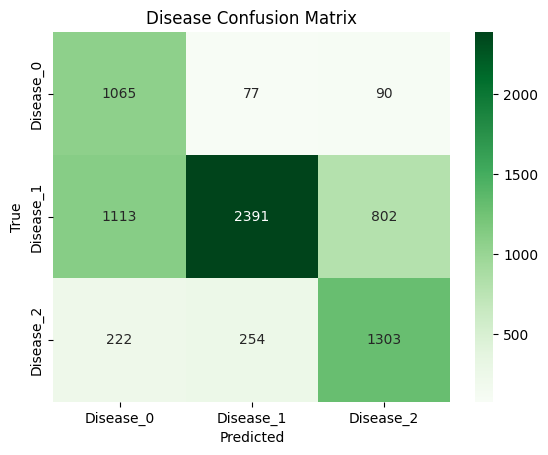


Activity Classification Report:
              precision    recall  f1-score   support

  Activity_0     0.7953    0.8403    0.8172       407
  Activity_1     0.9208    0.9271    0.9240       439
  Activity_2     0.9965    0.9829    0.9897      2050
  Activity_3     0.9578    0.9512    0.9545       430
  Activity_4     0.8506    0.8445    0.8475       418
  Activity_5     0.9722    0.9699    0.9710       432
  Activity_6     0.9833    0.9968    0.9900      1890
  Activity_7     0.8534    0.8555    0.8544       422
  Activity_8     0.9388    0.9020    0.9200       408
  Activity_9     0.9690    0.9644    0.9667       421

    accuracy                         0.9518      7317
   macro avg     0.9238    0.9235    0.9235      7317
weighted avg     0.9523    0.9518    0.9519      7317



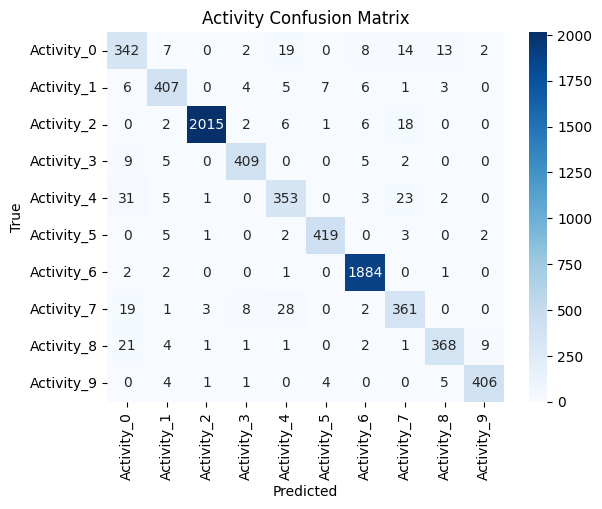

In [55]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ---- Predictions ----
y_pred_test = model.predict(X_test_scaled)

y_pred_disease = np.argmax(y_pred_test[0], axis=1)
y_pred_activity = np.argmax(y_pred_test[1], axis=1)

# ---- Disease Report ----
print("\nDisease Classification Report:")
print(classification_report(y_disease_test, y_pred_disease, target_names=[f"Disease_{i}" for i in range(3)], digits=4))

cm_disease = confusion_matrix(y_disease_test, y_pred_disease)
sns.heatmap(cm_disease, annot=True, fmt="d", cmap="Greens",
            xticklabels=[f"Disease_{i}" for i in range(3)],
            yticklabels=[f"Disease_{i}" for i in range(3)])
plt.title("Disease Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ---- Activity Report ----
print("\nActivity Classification Report:")
print(classification_report(y_activity_test, y_pred_activity, target_names=[f"Activity_{i}" for i in range(10)], digits=4))

cm_activity = confusion_matrix(y_activity_test, y_pred_activity)
sns.heatmap(cm_activity, annot=True, fmt="d", cmap="Blues",
            xticklabels=[f"Activity_{i}" for i in range(10)],
            yticklabels=[f"Activity_{i}" for i in range(10)])
plt.title("Activity Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
